# ANALYSIS 2. Detector Flux Analysis: run2_detector_flux_propagation
---
This notebook analyzes the detector-level atmospheric-neutrino flux files produced by `notebooks/runs/atmosphere/atmosphere2_detector_flux_propagation.py`. The saved tensors contain the initial production flux, the flux at the Earth surface after atmospheric propagation, and the final detector flux after Earth propagation.


## 1. Libraries

We use the public `flux_propagation` loading and aggregation helpers, plus Torch and Matplotlib for numerical inspection and visualization.


In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

from tpeanuts.flux_propagation import (
    aggregate_detector_conversion_by_mode,
    aggregate_detector_flux_by_mode,
    load_detector_flux_directory,
)

from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

torch.set_printoptions(precision=6, sci_mode=True)
plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.grid": True})
from tpeanuts.core.pmns import PMNS
from tpeanuts.atmosphere.propagation import atmospheric_evolution_operator, propagate_atmosphere
from tpeanuts.io.io_earth import load_earth_density_from_csv
from tpeanuts.earth.probabilities import pearth_numerical
from tpeanuts.atmosphere.geometry import theta_to_eta
from tpeanuts.util.constant import R_E_KM
from tpeanuts.atmosphere.density import atmospheric_electron_density_profile


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts


## 2. Simulation and System Parameters

Set the detector-flux directory generated by `run2_detector_flux_propagation.py`. The files are grouped by particle and then aggregated into neutrino and antineutrino samples.


### 2.1. Paths

All notebook outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. Figures are saved under the notebook-specific `OUTPUT_DIR`; display behavior is controlled in Section 2.2.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_ANALYSIS_ATMOSPHERE / "analysis_atmospher2_detector"

DATA_ATMOSPHERE_ROOT = OUTPUT_DATA_ATMOSPHERE
DETECTOR_ROOT = OUTPUT_DATA_ATMOSPHERE / "detector"
INPUT_DIR = str(DETECTOR_ROOT / "detector_flux_QGSJETII04_PolyGonato_ICECUBE")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Output root     :", OUTPUT_ROOT)
print("Input directory: ", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Input directory:  V:\output\data\atmosphere\detector\detector_flux_QGSJETII04_PolyGonato_ICECUBE
Output directory: V:\output\analysis\atmosphere\analysis_atmospher2_detector


### 2.2. Configuration Parameters

These parameters select the propagated atmospheric sample, plotting grid points, flavour labels, oscillation constants, and the pure-state diagnostic settings used later in the notebook. Set `ENERGY_GEV` or `ALPHA_DEG` to `None` to select representative grid points automatically.


In [3]:
DEVICE = "cpu"
DTYPE = torch.float64

SHOW_PLOTS = True

EARTH_DENSITY_FILE = str(PACKAGE_DIR / "data" / "density" / "earth_density.csv")

MODE = "nu"  # Choose "nu" or "antinu".
ENERGY_GEV = None
ALPHA_DEG = None
EPS = 1.0e-40

FLAVOURS = ["nue", "numu", "nutau"]
FLAVOUR_LABELS = {
    "nue": r"$\nu_e$",
    "numu": r"$\nu_\mu$",
    "nutau": r"$\nu_\tau$",
}

DM21_EV2 = 7.42e-5
DM3L_EV2 = 2.517e-3
THETA12 = 0.59
THETA13 = 0.15
THETA23 = 0.78
DELTA_CP = 1.20

ATM_COHERENT_H_START_KM = 80.0
ATM_COHERENT_ALPHA_DEG = 45.0
ATM_COHERENT_THETA_DEG = ATM_COHERENT_ALPHA_DEG
ATM_COHERENT_E_GEV = 0.1
ATM_COHERENT_N_H = 21
ATM_COHERENT_N_STEPS = 24

EARTH_COHERENT_DEPTH_M = 1000.0
EARTH_COHERENT_ALPHA_DEG = 135.0
EARTH_COHERENT_THETA_DEG = EARTH_COHERENT_ALPHA_DEG
EARTH_COHERENT_E_GEV = 0.1
EARTH_PATH_N_STEPS = 256

print("Device:", DEVICE)
print("Dtype :", DTYPE)
print("Mode  :", MODE)
print("Earth density file:", EARTH_DENSITY_FILE)


Device: cpu
Dtype : torch.float64
Mode  : nu
Earth density file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\density\earth_density.csv


## 3. Dataset Inventory and Propagation Grids

The atmospheric pipeline stores fluxes on an energy grid $E$ and detector-angle grid $\alpha$. The selected mode combines the produced flavour channels into tensors $\Phi_i(E,\alpha)$ with final-flavour index $i \in \{e,\mu,\tau\}$.


### 3.1. Load Flux Data

The detector-propagation output directory contains one saved torch file per produced particle and detector angle. Each file stores the energy grid, the production-height grid, the detector-angle metadata, and the propagated flux/probability arrays for that particle-angle combination. The loader groups those files by particle and the aggregator combines particles into neutrino (`nu`) and antineutrino (`antinu`) samples.

After aggregation, the main arrays used below are:

- `initial_flux_alpha_Ei`: initial height-integrated production flux, indexed as `[angle, energy, final_flavour]`. Before propagation, the flux remains in the produced flavour channel.
- `surface_flux_alpha_Ei`: flux at the Earth surface after coherent atmospheric propagation and height integration, indexed as `[angle, energy, final_flavour]`.
- `detector_flux_alpha_Ei`: final flux after atmospheric plus Earth propagation, indexed as `[angle, energy, final_flavour]`.
- `source_flux_alpha_E`: total source spectrum before flavour resolution, indexed as `[angle, energy]`.
- `E_grid_GeV`, `angle_grid_deg`, `alpha_grid_deg`, and `theta_grid_deg`: the grids used by these arrays. `angle_grid_deg` is the active plotting grid. It is `alpha` for alpha-mode files and falls back to `theta` for theta-mode files.


In [4]:
loaded_by_particle = load_detector_flux_directory(
    str(INPUT_DIR),
    map_location=DEVICE,
    dtype=DTYPE,
    device=DEVICE,
    group_by="particle",
)

aggregated = aggregate_detector_flux_by_mode(loaded_by_particle)

print("Particles loaded:", sorted(loaded_by_particle))
print("Aggregated modes:", sorted(aggregated))

if MODE not in aggregated:
    raise KeyError(f"MODE={MODE!r} not found. Available modes: {sorted(aggregated)}")

mode_data = aggregated[MODE]
E = mode_data["E_grid_GeV"]
angle = mode_data.get("angle_grid_deg", mode_data["alpha_grid_deg"])
angle_kind = mode_data.get("angle_grid_kind", "alpha")
angle_symbol = r"\theta" if angle_kind == "theta" else r"\alpha"
angle_name = "theta" if angle_kind == "theta" else "alpha"
alpha = angle
theta = mode_data["theta_grid_deg"]
contributors_by_angle = mode_data.get("contributors_by_angle", mode_data["contributors_by_alpha"])

e_idx = int(E.numel() // 2) if ENERGY_GEV is None else int(torch.argmin(torch.abs(E - ENERGY_GEV)).item())
a_idx = int(angle.numel() // 4) if ALPHA_DEG is None else int(torch.argmin(torch.abs(angle - ALPHA_DEG)).item())

print("Mode:", MODE)
print("Energy grid:", tuple(E.shape), "selected", float(E[e_idx]), "GeV")
print(f"{angle_name.title()} grid:", tuple(angle.shape), "selected", float(angle[a_idx]), "deg")
print("Theta at selected angle:", float(theta[a_idx]), "deg")
print("Contributing particles at selected angle:", contributors_by_angle[a_idx])


Particles loaded: ['antinue', 'antinumu', 'antinutau', 'nue', 'numu', 'nutau']
Aggregated modes: ['antinu', 'nu']
Mode: nu
Energy grid: (121,) selected 89125.09375 GeV
Theta grid: (10,) selected 41.40962219238281 deg
Theta at selected angle: 41.40962219238281 deg
Contributing particles at selected angle: ['nue', 'numu', 'nutau']


initial_flux_alpha_Ei : (10, 121, 3)
surface_flux_alpha_Ei : (10, 121, 3)
detector_flux_alpha_Ei: (10, 121, 3)
source_flux_alpha_E   : (10, 121)
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_001.png


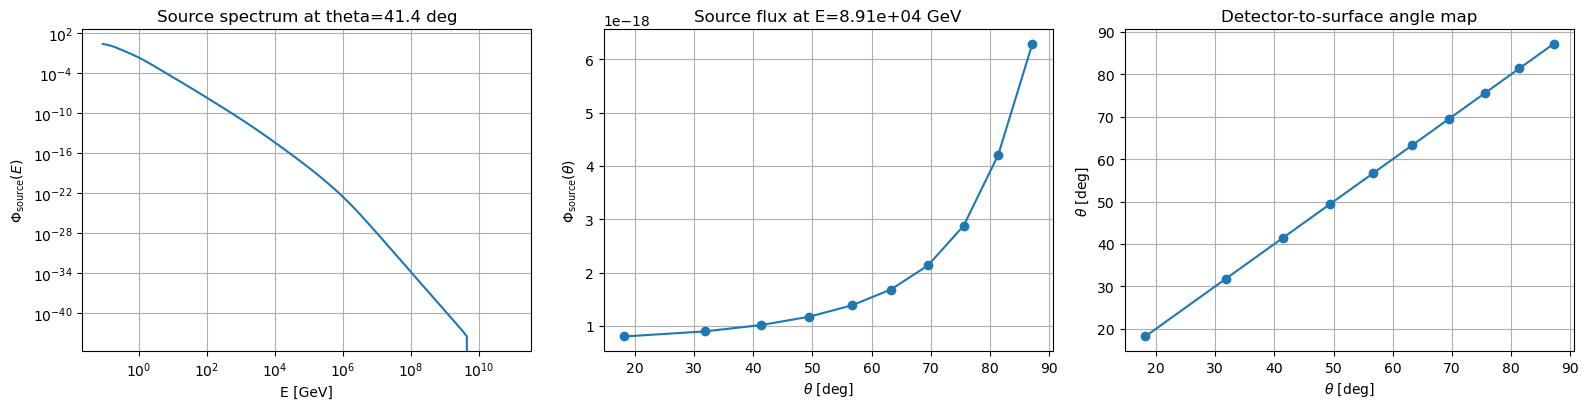

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_001.png')

In [5]:
initial_flux = mode_data["initial_flux_alpha_Ei"]
surface_flux = mode_data["surface_flux_alpha_Ei"]
detector_flux = mode_data["detector_flux_alpha_Ei"]
source_flux = mode_data["source_flux_alpha_E"]

print("initial_flux_alpha_Ei :", tuple(initial_flux.shape))
print("surface_flux_alpha_Ei :", tuple(surface_flux.shape))
print("detector_flux_alpha_Ei:", tuple(detector_flux.shape))
print("source_flux_alpha_E   :", tuple(source_flux.shape))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(E.cpu(), source_flux[a_idx].cpu())
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_xlabel("E [GeV]")
axes[0].set_ylabel(r"$\Phi_\mathrm{source}(E)$")
axes[0].set_title(f"Source spectrum at {angle_name}={float(angle[a_idx]):.1f} deg")
#axes[0].set_xlim(0,1e+7)
axes[1].plot(angle.cpu(), source_flux[:, e_idx].cpu(), marker="o")
axes[1].set_xlabel(rf"${angle_symbol}$ [deg]")
axes[1].set_ylabel(rf"$\Phi_\mathrm{{source}}({angle_symbol})$")
axes[1].set_title(f"Source flux at E={float(E[e_idx]):.3g} GeV")

axes[2].plot(angle.cpu(), theta.cpu(), marker="o")
axes[2].set_xlabel(rf"${angle_symbol}$ [deg]")
axes[2].set_ylabel(r"$\theta$ [deg]")
axes[2].set_title("Detector-to-surface angle map")

fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 4. Initial Production Flux

At the first saved stage, the flux has not yet been propagated. The tensor represents the height-integrated production flux assigned to the produced flavour channel,

$\Phi_i^0(E,\alpha)=\sum_\beta \delta_{i\beta}\int dh\,\Phi_\beta(E,h,\alpha)$.

This is the reference flux before atmospheric and Earth oscillation effects are applied.


**Function flow to this point**

- `load_detector_flux_directory(...)` reads every saved `.pt` file.
- `aggregate_detector_flux_by_mode(...)` groups particles into `nu` and `antinu` samples and stacks the tensors over the saved detector-angle grid.
- The plotted quantity is `initial_flux_alpha_Ei`.


Initial production total flux range:
min: 0.0
max: 2.584923565387726


C:\Users\juanr\AppData\Local\Temp\ipykernel_21728\3728295602.py:11: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[i].set_yscale("log")


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_002.png


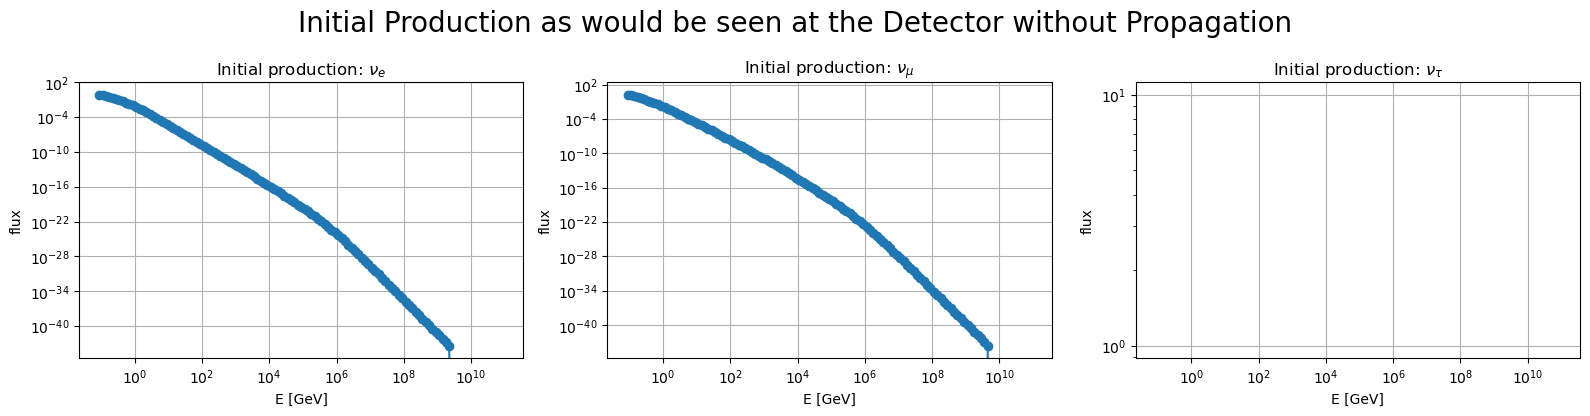

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_003.png


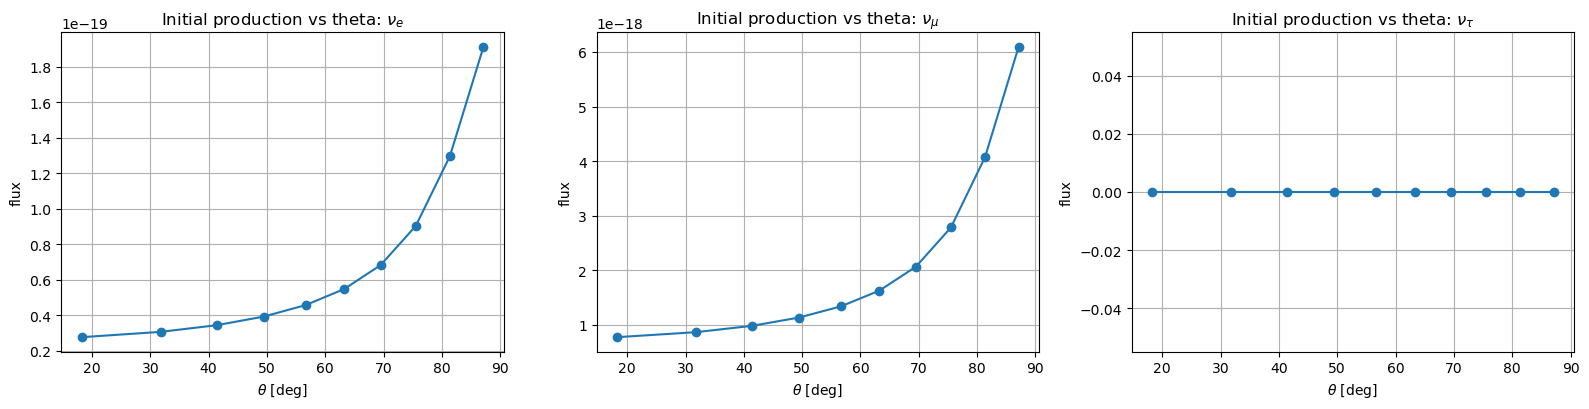

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_003.png')

In [6]:
stage = initial_flux
stage_name = "Initial production"

print(f"{stage_name} total flux range:")
print("min:", torch.min(stage.sum(dim=-1)).item())
print("max:", torch.max(stage.sum(dim=-1)).item())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for i, flavour in enumerate(FLAVOURS):
    axes[i].plot(E.cpu(), stage[a_idx, :, i].cpu(), marker="o")
    axes[i].set_yscale("log")
    axes[i].set_xscale("log")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_ylabel("flux")
    axes[i].set_title(f"{stage_name}: {FLAVOUR_LABELS[flavour]}")
    #axes[i].set_xlim(0, 1e1)
    #axes[i].set_ylim(1e-14, 1e2)
fig.suptitle('Initial Production as would be seen at the Detector without Propagation', fontsize=20)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for i, flavour in enumerate(FLAVOURS):
    axes[i].plot(angle.cpu(), stage[:, e_idx, i].cpu(), marker="o")
    axes[i].set_xlabel(rf"${angle_symbol}$ [deg]")
    axes[i].set_ylabel("flux")
    axes[i].set_title(f"{stage_name} vs {angle_name}: {FLAVOUR_LABELS[flavour]}")
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 5. Atmospheric Propagation to the Earth Surface

This section first inspects coherent atmospheric flavour evolution for pure initial states, then analyzes the saved height-integrated surface fluxes.


### 5.1. Coherent Atmospheric Evolution

Three pure flavour states are produced at 80 km altitude and propagated coherently through the atmosphere. The x-axis is the current altitude along the trajectory, from 80 km down to the Earth surface at 0 km, for fixed energy 0.1 GeV and alpha = 45 deg. The first point is therefore exactly the pure initial state.


Atmospheric coherent propagation for MODE=nu
Fixed energy : 0.1 GeV
Alpha/theta  : 45.0 deg
Initial h    : 80.0 km
Initial probabilities at h=80 km:
tensor([[1.000000e+00, 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 1.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, 1.000000e+00]], dtype=torch.float64)
Max normalization error: 1.3211653993039363e-14
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_004.png


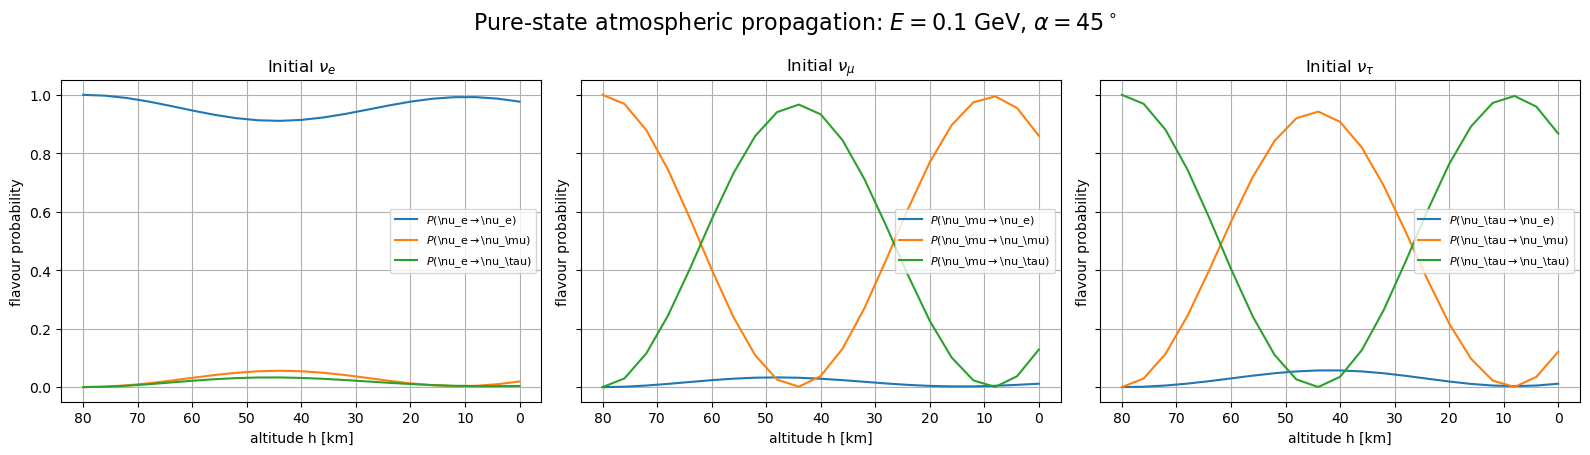

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_004.png')

In [7]:
pmns_atm = PMNS(
    THETA12,
    THETA13,
    THETA23,
    DELTA_CP,
    device=DEVICE,
    real_dtype=DTYPE,
)

h_atm_axis_km = torch.linspace(
    ATM_COHERENT_H_START_KM,
    0.0,
    ATM_COHERENT_N_H,
    device=DEVICE,
    dtype=DTYPE,
)
h_travelled_km = ATM_COHERENT_H_START_KM - h_atm_axis_km
E_atm_coherent_GeV = torch.tensor(ATM_COHERENT_E_GEV, device=DEVICE, dtype=DTYPE)
E_atm_coherent_MeV = 1.0e3 * E_atm_coherent_GeV
theta_atm_coherent_deg = torch.tensor(ATM_COHERENT_THETA_DEG, device=DEVICE, dtype=DTYPE)


def ne_profile_shifted_by_current_height(altitude_km, *, device=None, dtype=DTYPE):
    """Density for each partial trajectory from 80 km down to the current h."""
    altitude = torch.as_tensor(altitude_km, device=device, dtype=dtype)
    current_h = h_atm_axis_km.to(device=altitude.device, dtype=dtype)
    while current_h.ndim < altitude.ndim:
        current_h = current_h.unsqueeze(-1)
    return atmospheric_electron_density_profile(
        altitude + current_h,
        device=altitude.device,
        dtype=dtype,
    )

P_atm_by_initial = []
for initial_idx, initial_flavour in enumerate(FLAVOURS):
    state0 = torch.zeros(3, dtype=torch.complex128, device=DEVICE)
    state0[initial_idx] = 1.0 + 0.0j

    states_h, _ = propagate_atmosphere(
        nustate=state0,
        pmns=pmns_atm,
        DeltamSq21=DM21_EV2,
        DeltamSq3l=DM3L_EV2,
        E_MeV=E_atm_coherent_MeV,
        h_km=h_travelled_km,
        theta_deg=theta_atm_coherent_deg,
        depth_km=torch.tensor(0.0, device=DEVICE, dtype=DTYPE),
        antinu=(MODE == "antinu"),
        ne_profile=ne_profile_shifted_by_current_height,
        n_steps=ATM_COHERENT_N_STEPS,
        matter=True,
        device=DEVICE,
        dtype=DTYPE,
    )

    P_atm_by_initial.append(torch.abs(states_h) ** 2)

P_atm_path = torch.stack(P_atm_by_initial, dim=1)  # [h, initial, final]
print(f"Atmospheric coherent propagation for MODE={MODE}")
print(f"Fixed energy : {float(E_atm_coherent_GeV):.6g} GeV")
print(f"Alpha/theta  : {ATM_COHERENT_ALPHA_DEG:.1f} deg")
print(f"Initial h    : {ATM_COHERENT_H_START_KM:.1f} km")
print("Initial probabilities at h=80 km:")
print(P_atm_path[0])
print("Max normalization error:", float(torch.max(torch.abs(P_atm_path.sum(dim=-1) - 1.0))))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)
for initial_idx, initial_flavour in enumerate(FLAVOURS):
    ax = axes[initial_idx]
    for final_idx, final_flavour in enumerate(FLAVOURS):
        ax.plot(
            h_atm_axis_km.cpu(),
            P_atm_path[:, initial_idx, final_idx].detach().cpu(),
            label=rf"$P({FLAVOUR_LABELS[initial_flavour]} \to {FLAVOUR_LABELS[final_flavour]})$",
        )
    ax.set_xlabel("altitude h [km]")
    ax.set_ylabel("flavour probability")
    ax.set_title(f"Initial {FLAVOUR_LABELS[initial_flavour]}")
    ax.invert_xaxis()
    ax.legend(fontsize=8)

fig.suptitle(
    rf"Pure-state atmospheric propagation: $E={ATM_COHERENT_E_GEV:.1f}$ GeV, "
    rf"$\alpha={ATM_COHERENT_ALPHA_DEG:.0f}^\circ$",
    fontsize=16,
)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)



**Coherent-propagation formulae and interpretation**

For a pure initial flavour state produced at altitude $h_0=80\,\mathrm{km}$,

$$
|\nu(0)\rangle = |\nu_\alpha\rangle,
$$

the coherent atmospheric state at a later point along the trajectory is

$$
|\nu(x)\rangle = S_{\rm atm}(x,0;E,\theta)\,|\nu_\alpha\rangle,
$$

with evolution operator

$$
S_{\rm atm}(x,0)=\mathcal{T}\exp\left[-i\int_0^x H_{\rm atm}(x';E,n_e(x'))\,dx'\right].
$$

The plotted probabilities are therefore

$$
P_{\alpha\to\beta}(x)=|\langle\nu_\beta|\nu(x)\rangle|^2
=\left|\left[S_{\rm atm}(x,0)\right]_{\beta\alpha}\right|^2.
$$

At $E=0.1\,\mathrm{GeV}$ the vacuum oscillation length associated with $\Delta m^2_{31}$ is short enough that sizeable phase differences can accumulate even across atmospheric baselines. The electron flavour is comparatively less variable here because $\nu_e$ couples to the third mass state mainly through the smaller angle $\theta_{13}$, and the atmospheric matter density is too small to create a strong matter enhancement at this energy and path length. By contrast, $\nu_\mu$ and $\nu_\tau$ are strongly mixed by the large atmospheric angle $\theta_{23}$, so their amplitudes exchange efficiently and the corresponding probabilities vary much more strongly.


### 5.2. Earth-Surface Flux after Atmospheric Propagation

The atmospheric stage propagates coherent flavour states from production height to the Earth surface. After weighting by the production-height flux and integrating over $h$, the saved surface flux is

$\Phi_i^\mathrm{surf}(E,\alpha)=\sum_\beta\int dh\,\Phi_\beta(E,h,\alpha)P^\mathrm{atm}_{\beta\to i}(E,h,\alpha)$.

The ratio $\Phi_i^\mathrm{surf}/\Phi_i^0$ is a compact diagnostic of atmospheric oscillation and matter effects before Earth crossing.


**Function flow for the saved 5.2 surface-flux data**

- `propagate_atmosphere_coherent(...)` computes coherent atmospheric states for each produced flavour.
- `integrate_initial_and_surface_fluxes(...)` integrates height-resolved probabilities against the MCEq production flux.
- The plotted quantity is `surface_flux_alpha_Ei`, compared to `initial_flux_alpha_Ei`.


Earth surface total flux range:
min: 0.0
max: 2.5849235206842422
Total surface / initial at selected alpha: 0.9999999954526898
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_005.png


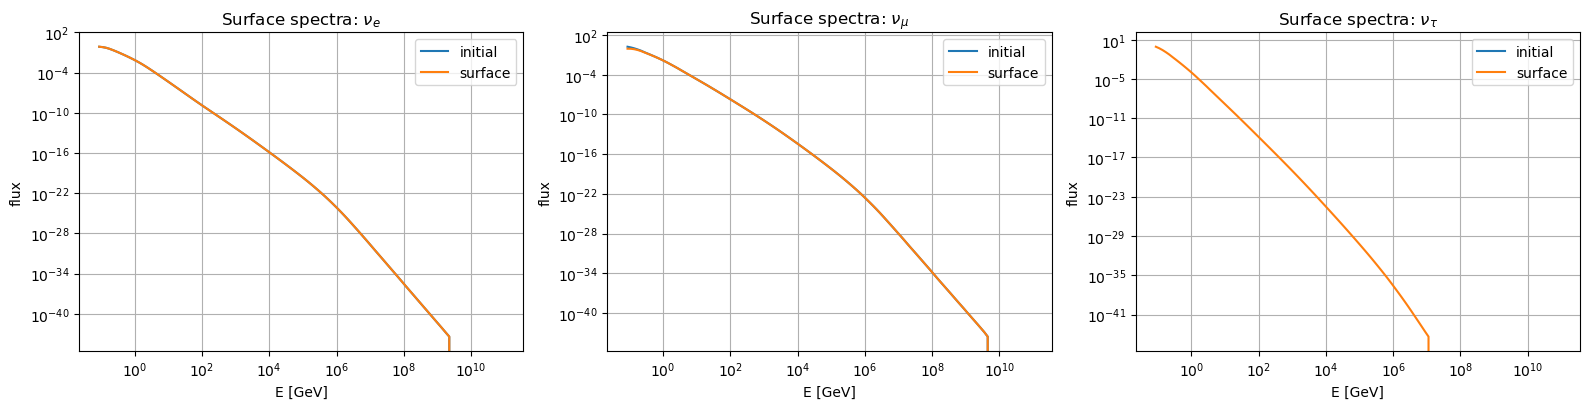

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_006.png


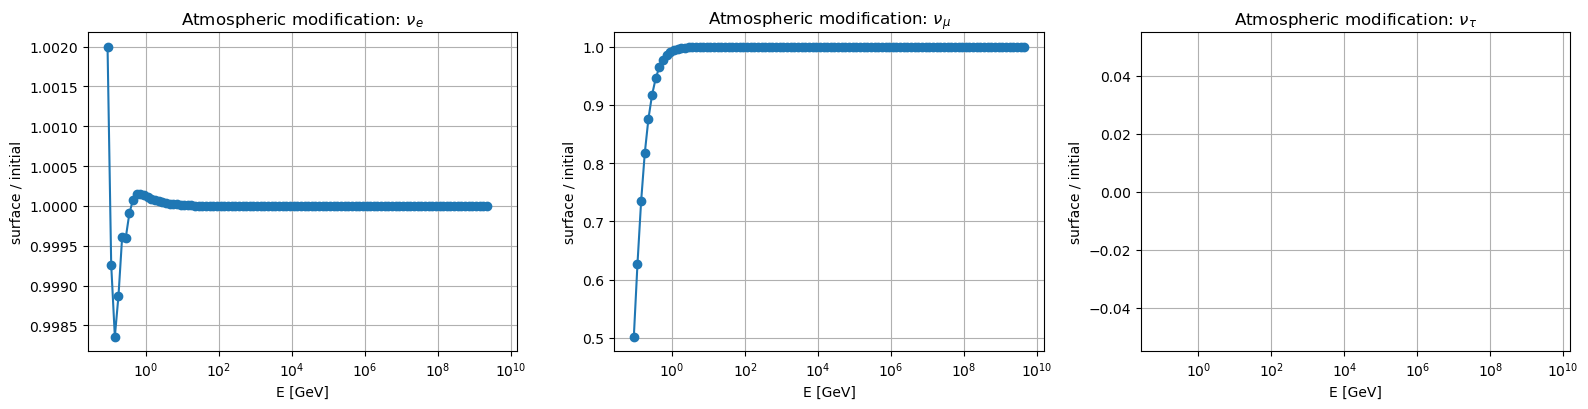

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_006.png')

In [8]:
stage = surface_flux
reference = initial_flux
stage_name = "Earth surface"
ratio = stage / reference
print(f"{stage_name} total flux range:")
print("min:", torch.min(stage.sum(dim=-1)).item())
print("max:", torch.max(stage.sum(dim=-1)).item())
print("Total surface / initial at selected alpha:", float(stage[a_idx].sum() / torch.clamp(reference[a_idx].sum(), min=EPS)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for i, flavour in enumerate(FLAVOURS):
    axes[i].plot(E.cpu(), reference[a_idx, :, i].cpu(), label="initial")
    axes[i].plot(E.cpu(), stage[a_idx, :, i].cpu(), label="surface")
    axes[i].set_yscale("log")
    axes[i].set_xscale("log")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_ylabel("flux")
    axes[i].set_title(f"Surface spectra: {FLAVOUR_LABELS[flavour]}")
    axes[i].legend()
    
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for i, flavour in enumerate(FLAVOURS):
    axes[i].plot(E.cpu(), ratio[a_idx, :, i].cpu(), marker="o")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_xscale("log")
    axes[i].set_ylabel("surface / initial")
    axes[i].set_title(f"Atmospheric modification: {FLAVOUR_LABELS[flavour]}")
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Earth Propagation to the Detector

This section first inspects coherent Earth evolution along the underground trajectory, then analyzes the saved detector flux after Earth propagation.


### 6.1. Coherent Earth Evolution

Three pure flavour states are produced at the Earth surface and propagated coherently through Earth to a detector at 1000 m depth. The x-axis is the travelled distance from the surface to the detector for fixed energy 0.1 GeV and alpha = 135 deg.


Earth coherent diagnostic for MODE=nu
Fixed energy  : 0.1 GeV
Alpha/theta   : 135.0 deg
Eta           : 0.785398 rad
Detector depth: 1000.0 m
Path length   : 9009.95 km
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_007.png


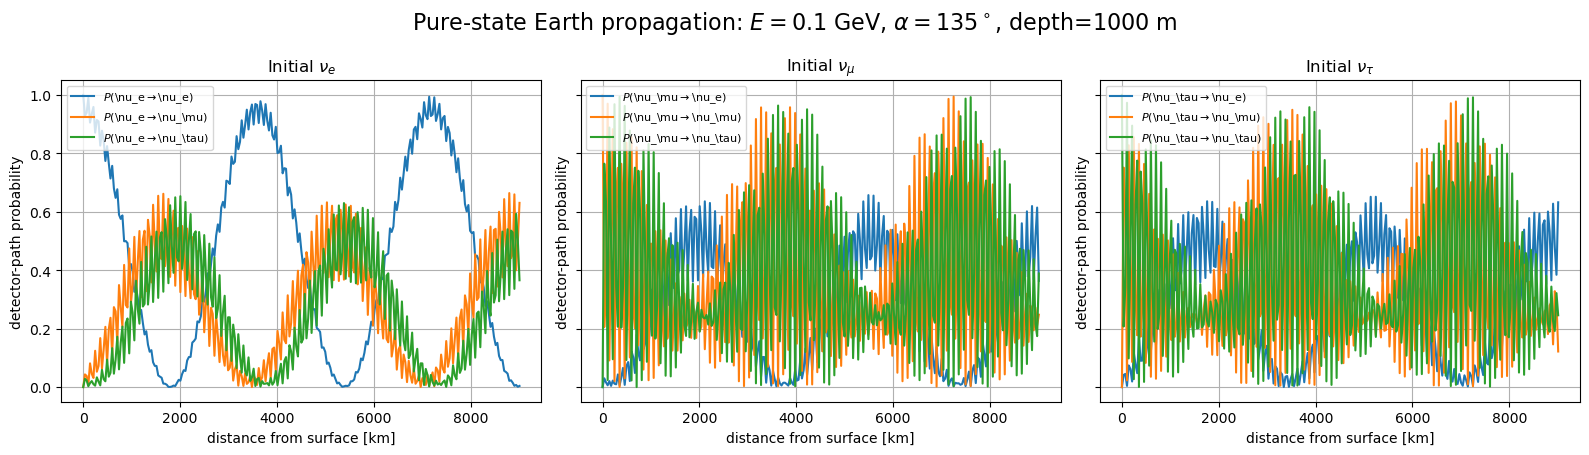

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_007.png')

In [9]:
earth_density = load_earth_density_from_csv(
    EARTH_DENSITY_FILE,
    device=DEVICE,
    dtype=DTYPE,
)

pmns_earth = PMNS(
    THETA12,
    THETA13,
    THETA23,
    DELTA_CP,
    device=DEVICE,
    real_dtype=DTYPE,
)

eta_earth = theta_to_eta(
    torch.tensor(EARTH_COHERENT_THETA_DEG, device=DEVICE, dtype=DTYPE),
    device=DEVICE,
    dtype=DTYPE,
)

E_earth_GeV = torch.tensor(EARTH_COHERENT_E_GEV, device=DEVICE, dtype=DTYPE)
E_earth_MeV = 1.0e3 * E_earth_GeV

P_earth_by_initial = []
x_earth = None
for initial_idx in range(3):
    state = torch.zeros(3, dtype=torch.complex128, device=DEVICE)
    state[initial_idx] = 1.0 + 0.0j
    evolution, x_grid = pearth_numerical(
        nustate=state,
        density=earth_density,
        pmns=pmns_earth,
        dm21_eV2=DM21_EV2,
        dm3l_eV2=DM3L_EV2,
        E_MeV=E_earth_MeV,
        eta=eta_earth,
        depth_m=EARTH_COHERENT_DEPTH_M,
        massbasis=False,
        full_oscillation=True,
        nsteps=EARTH_PATH_N_STEPS,
        ode_method="midpoint",
        device=DEVICE,
        dtype=DTYPE,
    )
    P_earth_by_initial.append(evolution)
    x_earth = x_grid

P_earth_path = torch.stack(P_earth_by_initial, dim=1)  # [path, initial, final]
distance_from_surface_km = (x_earth - x_earth[0]) * R_E_KM

print(f"Earth coherent diagnostic for MODE={MODE}")
print(f"Fixed energy  : {float(E_earth_GeV):.6g} GeV")
print(f"Alpha/theta   : {EARTH_COHERENT_ALPHA_DEG:.1f} deg")
print(f"Eta           : {float(eta_earth):.6g} rad")
print(f"Detector depth: {EARTH_COHERENT_DEPTH_M:.1f} m")
print(f"Path length   : {float(distance_from_surface_km[-1]):.6g} km")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)
for initial_idx, initial_flavour in enumerate(FLAVOURS):
    ax = axes[initial_idx]
    for final_idx, final_flavour in enumerate(FLAVOURS):
        ax.plot(
            distance_from_surface_km.detach().cpu(),
            P_earth_path[:, initial_idx, final_idx].detach().cpu(),
            label=rf"$P({FLAVOUR_LABELS[initial_flavour]} \to {FLAVOUR_LABELS[final_flavour]})$",
        )
    ax.set_xlabel("distance from surface [km]")
    ax.set_ylabel("detector-path probability")
    ax.set_title(f"Initial {FLAVOUR_LABELS[initial_flavour]}")
    ax.legend(fontsize=8)

fig.suptitle(
    rf"Pure-state Earth propagation: $E={float(E_earth_GeV):.3g}$ GeV, "
    rf"$\alpha={EARTH_COHERENT_ALPHA_DEG:.0f}^\circ$, depth={EARTH_COHERENT_DEPTH_M:.0f} m",
    fontsize=16,
)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)



**Earth coherent-propagation formulae and interpretation**

For the Earth segment, the pure state is initialized at the surface,

$$
|\nu(0)\rangle = |\nu_\alpha\rangle,
$$

and propagated to a detector at depth $d=1000\,\mathrm{m}$ through

$$
|\nu(x)\rangle = S_{\oplus}(x,0;E,\eta,n_e)\,|\nu_\alpha\rangle,
$$

where

$$
S_{\oplus}(x,0)=\mathcal{T}\exp\left[-i\int_0^x H_{\oplus}(x';E,n_e(x'))\,dx'\right],
\qquad
P_{\alpha\to\beta}(x)=\left|\left[S_{\oplus}(x,0)\right]_{\beta\alpha}\right|^2.
$$

For the same travelled distance, Earth propagation can show stronger oscillations than the atmospheric segment because the neutrino is moving through much denser matter and, for an upward-going trajectory such as $\alpha=135^\circ$, the geometric path through Earth is very long. The denser medium changes the effective Hamiltonian, while the long baseline lets the oscillation phases accumulate many times.

The dominant exchange is usually between $\nu_\mu$ and $\nu_\tau$ because the atmospheric mixing angle $\theta_{23}$ is large, close to maximal. In the standard three-flavour structure, $\nu_\mu$ and $\nu_\tau$ have strong overlap with the mass eigenstates separated by $\Delta m^2_{31}$, so they preferentially oscillate into each other. The electron flavour participates through $\theta_{13}$ and $\theta_{12}$, but those couplings are smaller in this channel, so $\nu_e$ conversion is typically less dominant unless matter effects bring the system close to a resonance.


### 6.2. Detector Flux after Earth Propagation

The Earth stage applies the Earth evolution operator to the coherent surface states. After the height integration and flavour sum, the saved detector flux is

$\Phi_i^D(E,\alpha)=\sum_\beta\int dh\,\Phi_\beta(E,h,\alpha)P_{\beta\to i}^{\mathrm{atm}+\oplus}(E,h,\alpha)$.

The detector-to-surface ratio $\Phi_i^D/\Phi_i^\mathrm{surf}$ isolates the net Earth-crossing effect for each final flavour.


**Function flow for the saved 6.2 detector-flux data**

- `propagate_earth_coherent(...)` applies the Earth evolution operator to surface states.
- `integrate_height_and_sum_flavours(...)` builds the final detector flux by integrating over production height and summing produced flavours.
- The plotted quantity is `detector_flux_alpha_Ei`, compared with `surface_flux_alpha_Ei`.


Detector total flux range:
min: 0.0
max: 2.584923468530178
Total detector / surface at selected alpha: 1.0000000162005618
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_008.png


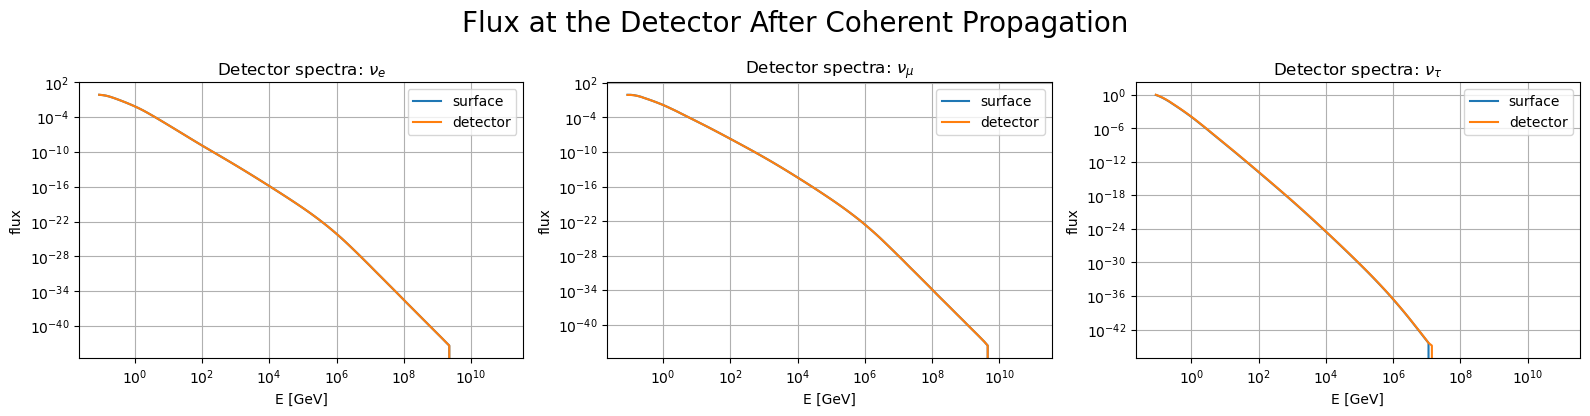

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_009.png


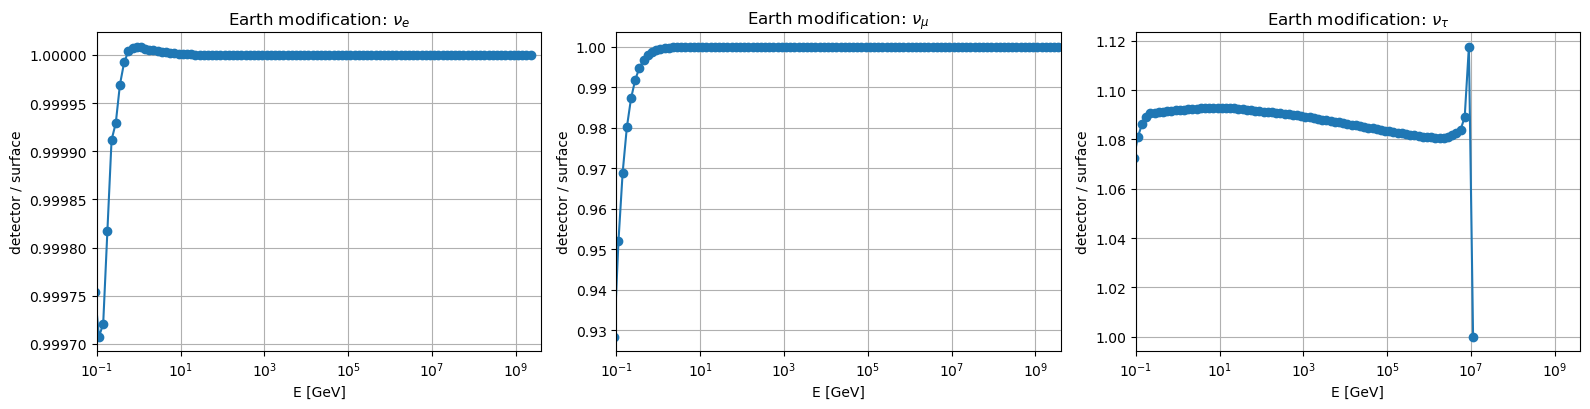

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_010.png


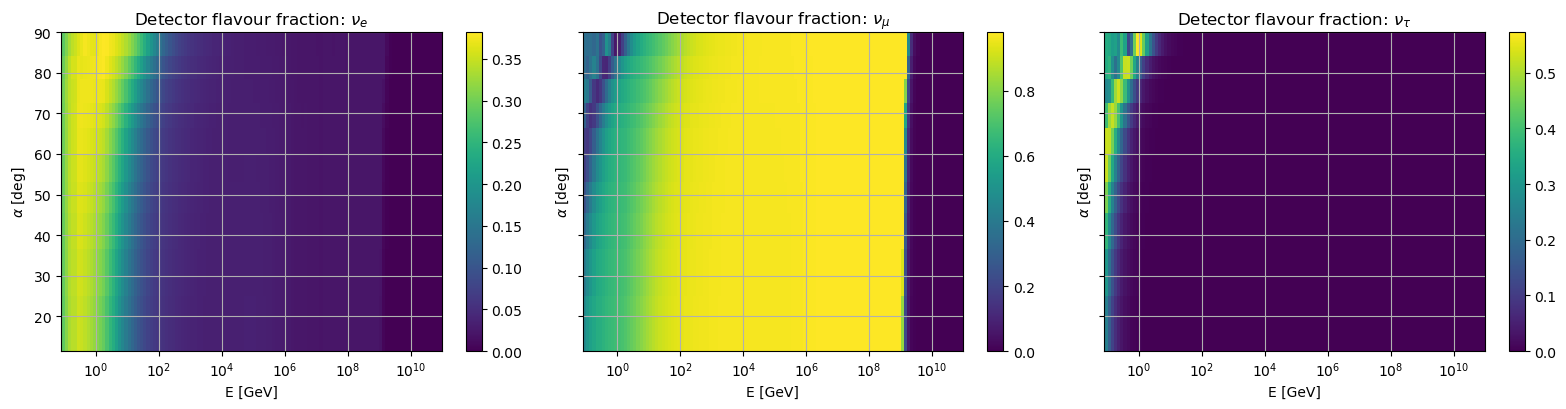

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_010.png')

In [10]:
stage = detector_flux
reference = surface_flux
stage_name = "Detector"
ratio = stage / torch.clamp(reference, min=EPS)
ratio = stage / reference
flavour_fraction = stage / torch.clamp(stage.sum(dim=-1, keepdim=True), min=EPS)

print(f"{stage_name} total flux range:")
print("min:", torch.min(stage.sum(dim=-1)).item())
print("max:", torch.max(stage.sum(dim=-1)).item())
print("Total detector / surface at selected alpha:", float(stage[a_idx].sum() / torch.clamp(reference[a_idx].sum(), min=EPS)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for i, flavour in enumerate(FLAVOURS):
    axes[i].plot(E.cpu(), reference[a_idx, :, i].cpu(), label="surface")
    axes[i].plot(E.cpu(), stage[a_idx, :, i].cpu(), label="detector")
    axes[i].set_yscale("log")
    axes[i].set_xscale("log")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_ylabel("flux")
    axes[i].set_title(f"Detector spectra: {FLAVOUR_LABELS[flavour]}")
    axes[i].legend()
    #axes[i].set_xlim(0, 1e1)
    #axes[i].set_ylim(1e-14, 1e2)
fig.suptitle('Flux at the Detector After Coherent Propagation', fontsize=20)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True)
for i, flavour in enumerate(FLAVOURS):
    axes[i].plot(E.cpu(), ratio[a_idx, :, i].cpu(), marker="o")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_ylabel("detector / surface")
    axes[i].set_title(f"Earth modification: {FLAVOUR_LABELS[flavour]}")
    axes[i].set_xscale("log")
    axes[i].set_xlim(1e-1,0.4*1e10)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
for i, flavour in enumerate(FLAVOURS):
    mesh = axes[i].pcolormesh(E.cpu(), alpha.cpu(), flavour_fraction[:, :, i].cpu(), shading="auto")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_ylabel(r"$\alpha$ [deg]")
    axes[i].set_title(f"Detector flavour fraction: {FLAVOUR_LABELS[flavour]}")
    axes[i].set_xscale("log")
    fig.colorbar(mesh, ax=axes[i])
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 7. Detector Conversion Spectra by Initial Flavour

This diagnostic uses the saved per-particle probabilities to reconstruct the detector transition spectra $P_{\beta\to\alpha}^D(E)$ at the selected detector angle. Each panel fixes the initial flavour $\nu_\beta$ and shows the final probabilities into $\nu_e$, $\nu_\mu$, and $\nu_\tau$.

The plotted quantity is the detector probability already stored by `run2_detector_flux_propagation.py`, after atmospheric propagation, Earth propagation, and production-height integration.


**Function flow to this point**

- `load_detector_flux_directory(..., group_by="particle")` loads one saved result per produced particle and angle.
- `aggregate_detector_conversion_by_mode(...)` stacks `detector_probability_Ei` into `detector_probability_alpha_beta_Ei`.
- The plotted tensor is indexed as `[angle, initial_flavour, E, final_flavour]`.


Detector conversion probability normalization at selected alpha:
nue   0.0 1.000000027362944
numu  0.0 1.0000000274894774
nutau 0.0 0.0
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_011.png


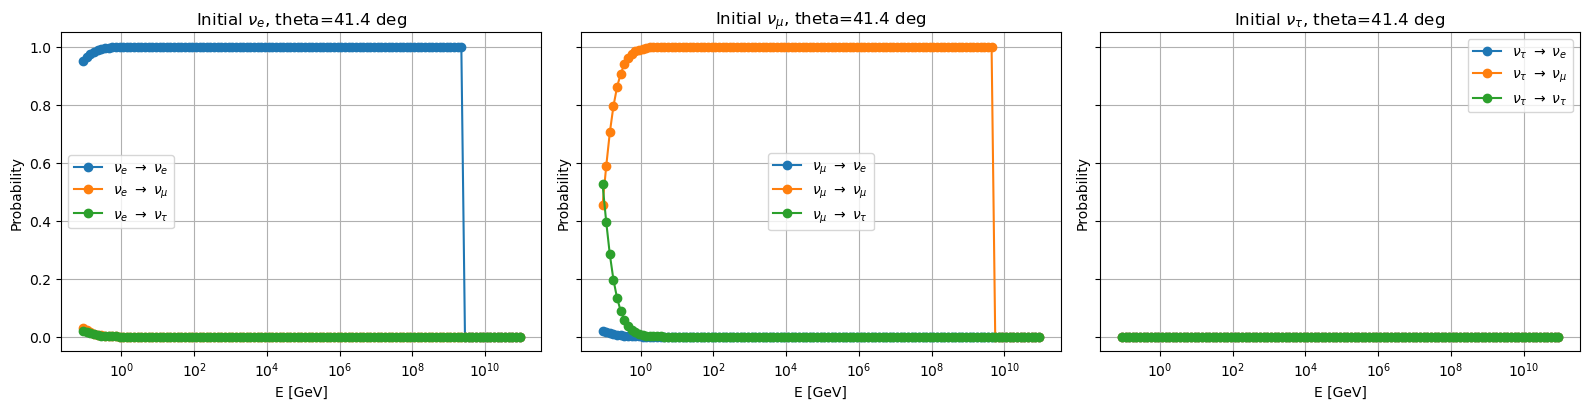

WindowsPath('V:/output/analysis/atmosphere/analysis_atmospher2_detector/figure_011.png')

In [11]:
conversion_by_mode = aggregate_detector_conversion_by_mode(
    loaded_by_particle,
    flavour_order=FLAVOURS,
)

if MODE not in conversion_by_mode:
    raise KeyError(f"MODE={MODE!r} not found in conversion data. Available: {sorted(conversion_by_mode)}")

conversion_data = conversion_by_mode[MODE]
conversion_prob = conversion_data["detector_probability_alpha_beta_Ei"]

print("Detector conversion probability normalization at selected alpha:")
for i, initial in enumerate(conversion_data["flavour_order"]):
    sums = conversion_prob[a_idx, i].sum(dim=-1)
    sums_np = sums.detach().cpu().numpy()
    print(f"{initial:5s}", float(np.nanmin(sums_np)), float(np.nanmax(sums_np)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
for i, initial in enumerate(conversion_data["flavour_order"]):
    for j, final in enumerate(conversion_data["flavour_order"]):
        axes[i].plot(
            E.cpu(),
            conversion_prob[a_idx, i, :, j].cpu(),
            marker="o",
            label=rf"{FLAVOUR_LABELS[initial]} $\to$ {FLAVOUR_LABELS[final]}",
        )
    axes[i].set_xscale("log")
    axes[i].set_xlabel("E [GeV]")
    axes[i].set_ylabel("Probability")
    axes[i].set_title(f"Initial {FLAVOUR_LABELS[initial]}, {angle_name}={float(angle[a_idx]):.1f} deg")
    axes[i].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 8. Stage Summary

This final panel compares the initial, surface, and detector fluxes in a 3x3 layout: columns are final flavours and rows are three representative energy values.


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher2_detector\figure_012.png


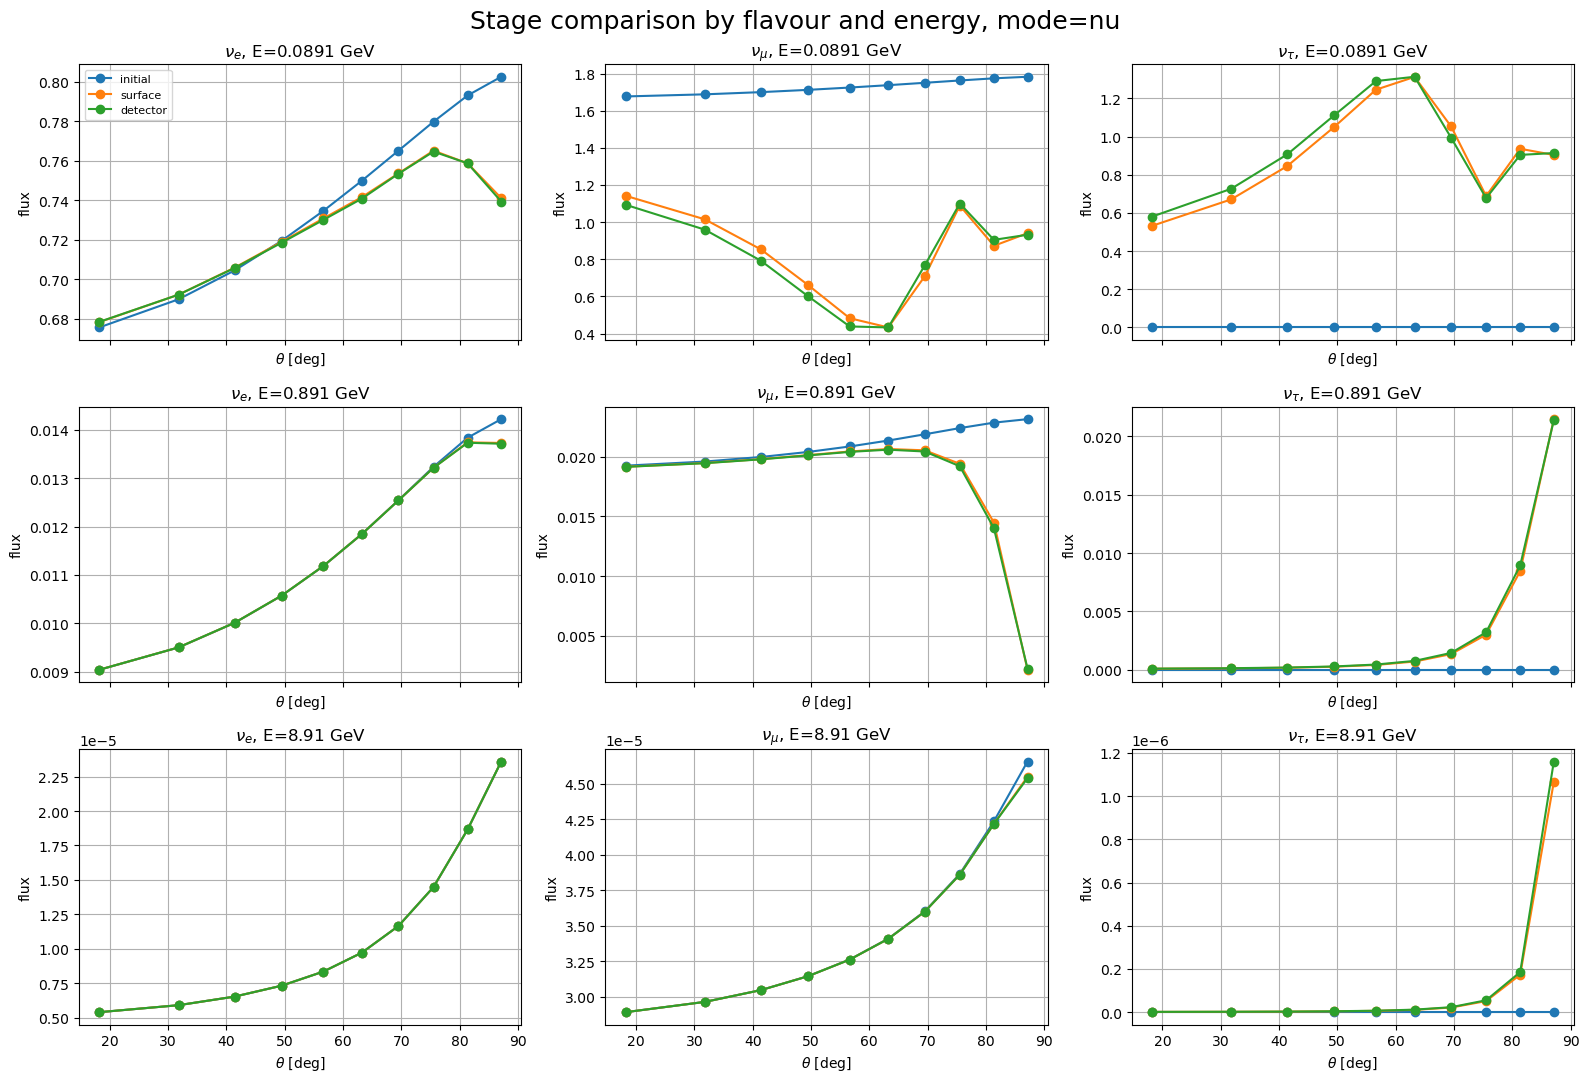

Integrated totals over theta and energy:
initial : 88.23238761861003
surface : 88.23238749729643
detector: 88.23238741938748


In [12]:
stage_tensors = {
    "initial": initial_flux,
    "surface": surface_flux,
    "detector": detector_flux,
}

energy_targets_GeV = torch.tensor([0.1, 1.0, 10.0], dtype=DTYPE)
energy_indices = [int(torch.argmin(torch.abs(E - value)).item()) for value in energy_targets_GeV]

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
for row, idx_E in enumerate(energy_indices):
    for col, flavour in enumerate(FLAVOURS):
        ax = axes[row, col]
        for stage_name, tensor in stage_tensors.items():
            ax.plot(
                angle.cpu(),
                tensor[:, idx_E, col].cpu(),
                marker="o",
                label=stage_name,
            )
        #ax.set_yscale("log")
        ax.set_title(f"{FLAVOUR_LABELS[flavour]}, E={float(E[idx_E]):.3g} GeV")
        ax.set_xlabel(rf"${angle_symbol}$ [deg]")
        ax.set_ylabel("flux")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(f"Stage comparison by flavour and energy, mode={MODE}", fontsize=18)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print(f"Integrated totals over {angle_name} and energy:")
for stage_name, tensor in stage_tensors.items():
    print(f"{stage_name:8s}:", float(tensor.sum()))
